In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flipkart-laptops-skus/flipkart_laptops.csv
/kaggle/input/skus-flipkart/skus flipkart.jpg


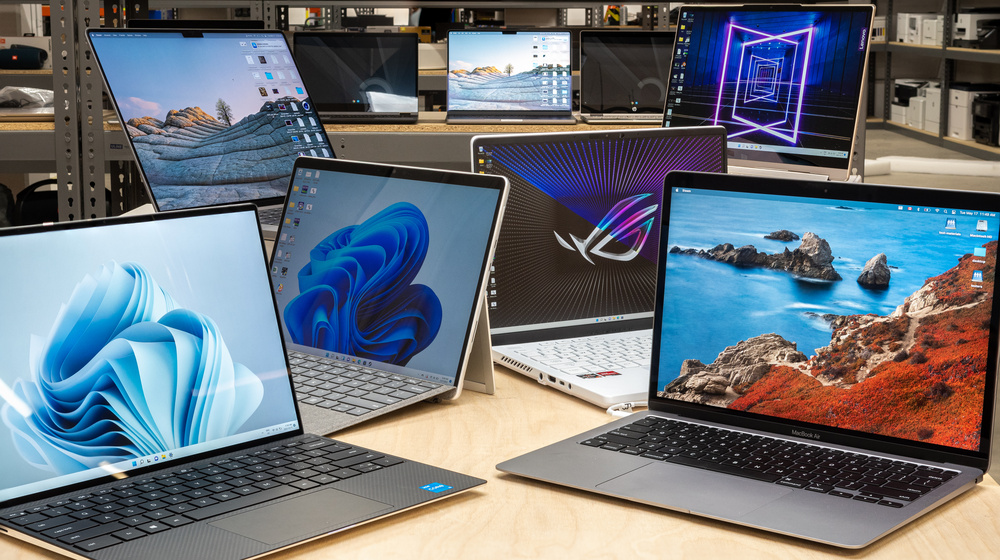

In [20]:
from IPython.display import Image, display
display(Image(filename="/kaggle/input/skus-flipkart/skus flipkart.jpg"))


In [14]:
# 1) Imports and load
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")  # seaborn style

# Path to your uploaded file
PATH = "/kaggle/input/flipkart-laptops-skus/flipkart_laptops.csv"

# Load with fallback encoding
df = pd.read_csv(PATH, low_memory=False, encoding='latin1')


print("Loaded shape:", df.shape)
df.head()



Loaded shape: (414, 8)


,Name,Brand,Sellig Price,MRP,Discount,Ratings,No_of_ratings,Details
0,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/256 ...,Lenovo,36990,60890,39% off,4.2,670 Ratings & 54 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
1,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/512 ...,Lenovo,37990,59390,36% off,4.2,3803 Ratings & 362 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
2,ASUS VivoBook 15 (2022) Core i3 10th Gen - (8 ...,ASUS,32990,45990,28% off,4.3,8727 Ratings & 876 Reviews,['Intel Core i3 Processor (10th Gen)' '8 GB DD...
3,realme Book (Slim) Core i3 11th Gen - (8 GB/25...,realme,46990,54999,14% off,4.4,11894 Ratings & 1773 Reviews,['Stylish & Portable Thin and Light Laptop' '1...
4,DELL Inspiron Core i3 11th Gen - (8 GB/1 TB HD...,DELL,38990,61202,36% off,4.3,65 Ratings & 6 Reviews,['Processor: Intel i3-1115G4 (Base- 1.70 GHz &...


In [21]:
# 2) Quick look
print("Columns:", list(df.columns))
print("\nData types:\n", df.dtypes.value_counts())
print("\nTop 5 rows:")
display(df.head())
print("\nBasic describe (numerical):")
display(df.describe().T)
print("\nBasic describe (all):")
display(df.describe(include='all').T)


Columns: ['Name', 'Brand', 'Sellig Price', 'MRP', 'Discount', 'Ratings', 'No_of_ratings', 'Details']

Data types:
 object     5
int64      2
float64    1
Name: count, dtype: int64

Top 5 rows:


,Name,Brand,Sellig Price,MRP,Discount,Ratings,No_of_ratings,Details
0,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/256 ...,Lenovo,36990,60890,39% off,4.2,670 Ratings & 54 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
1,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/512 ...,Lenovo,37990,59390,36% off,4.2,3803 Ratings & 362 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
2,ASUS VivoBook 15 (2022) Core i3 10th Gen - (8 ...,ASUS,32990,45990,28% off,4.3,8727 Ratings & 876 Reviews,['Intel Core i3 Processor (10th Gen)' '8 GB DD...
3,realme Book (Slim) Core i3 11th Gen - (8 GB/25...,realme,46990,54999,14% off,4.4,11894 Ratings & 1773 Reviews,['Stylish & Portable Thin and Light Laptop' '1...
4,DELL Inspiron Core i3 11th Gen - (8 GB/1 TB HD...,DELL,38990,61202,36% off,4.3,65 Ratings & 6 Reviews,['Processor: Intel i3-1115G4 (Base- 1.70 GHz &...



Basic describe (numerical):


,count,mean,std,min,25%,50%,75%,max
Sellig Price,414.0,69708.077295,42953.589855,14990.0,40990.0,59685.0,81742.5,309490.0
MRP,414.0,89741.393720,50538.944474,24418.0,56171.5,76990.0,106763.0,350990.0
Ratings,414.0,4.284300,0.333620,2.5,4.1,4.3,4.5,5.0



Basic describe (all):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,414,404,ASUS TUF Gaming F15 Core i5 10th Gen - (8 GB/1...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,414,17,ASUS,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sellig Price,414.0,NaN,NaN,NaN,69708.077295,42953.589855,14990.0,40990.0,59685.0,81742.5,309490.0
MRP,414.0,NaN,NaN,NaN,89741.39372,50538.944474,24418.0,56171.5,76990.0,106763.0,350990.0
Discount,414,44,25% off,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ratings,414.0,NaN,NaN,NaN,4.2843,0.33362,2.5,4.1,4.3,4.5,5.0
No_of_ratings,414,329,3 Ratings & 0 Reviews,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Details,414,385,['Apple M1 Processor' '8 GB DDR4 RAM' 'Mac OS ...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# 3) Normalize column names and strip whitespace
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns = df.columns.str.replace(r'[^\w]', '_', regex=True)  # keep safe names
print("Normalized columns:", list(df.columns))

# Helper printing function
def show_info(df, n=5):
    print("Shape:", df.shape)
    print("Null counts (top 10):\n", df.isnull().sum().sort_values(ascending=False).head(10))
    print("Duplicate rows:", df.duplicated().sum())
    display(df.head(n))

show_info(df)


Normalized columns: ['name', 'brand', 'sellig_price', 'mrp', 'discount', 'ratings', 'no_of_ratings', 'details']
Shape: (414, 8)
Null counts (top 10):
 name             0
brand            0
sellig_price     0
mrp              0
discount         0
ratings          0
no_of_ratings    0
details          0
dtype: int64
Duplicate rows: 0


,name,brand,sellig_price,mrp,discount,ratings,no_of_ratings,details
0,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/256 ...,Lenovo,36990,60890,39% off,4.2,670 Ratings & 54 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
1,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/512 ...,Lenovo,37990,59390,36% off,4.2,3803 Ratings & 362 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
2,ASUS VivoBook 15 (2022) Core i3 10th Gen - (8 ...,ASUS,32990,45990,28% off,4.3,8727 Ratings & 876 Reviews,['Intel Core i3 Processor (10th Gen)' '8 GB DD...
3,realme Book (Slim) Core i3 11th Gen - (8 GB/25...,realme,46990,54999,14% off,4.4,11894 Ratings & 1773 Reviews,['Stylish & Portable Thin and Light Laptop' '1...
4,DELL Inspiron Core i3 11th Gen - (8 GB/1 TB HD...,DELL,38990,61202,36% off,4.3,65 Ratings & 6 Reviews,['Processor: Intel i3-1115G4 (Base- 1.70 GHz &...


In [23]:
# 4) Detect numeric-like columns (heuristic by name) and convert safely
num_name_tokens = ['price','mrp','amount','discount','rating','review','count','qty','quantity','stock']
num_cols = [c for c in df.columns if any(tok in c for tok in num_name_tokens)]
num_cols = list(dict.fromkeys(num_cols))  # unique-preserve order
print("Candidate numeric columns:", num_cols)

for c in num_cols:
    # Remove non-digit except dot and minus, convert to numeric (keep NaN for missing)
    tmp = df[c].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)
    df[c] = pd.to_numeric(tmp.replace('', np.nan), errors='coerce')

# Detect date-like columns and convert
date_cols = [c for c in df.columns if 'date' in c or 'time' in c or 'launch' in c]
print("Candidate date columns:", date_cols)
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# Show conversions
display(df[num_cols + date_cols].head())


Candidate numeric columns: ['sellig_price', 'mrp', 'discount', 'ratings', 'no_of_ratings']
Candidate date columns: []


,sellig_price,mrp,discount,ratings,no_of_ratings
0,36990,60890,39,4.2,67054
1,37990,59390,36,4.2,3803362
2,32990,45990,28,4.3,8727876
3,46990,54999,14,4.4,118941773
4,38990,61202,36,4.3,656


Series([], dtype: int64)

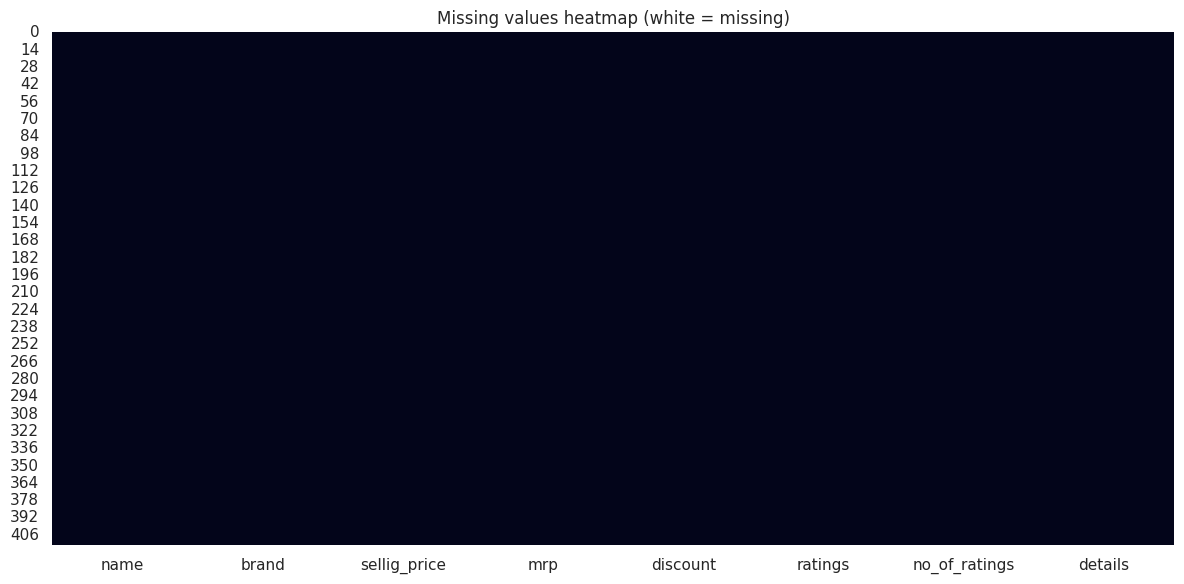

In [27]:
# 5) Missing values
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

# Visual: missingness heatmap (columns with any missing)
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing values heatmap (white = missing)")
plt.tight_layout()
plt.show()


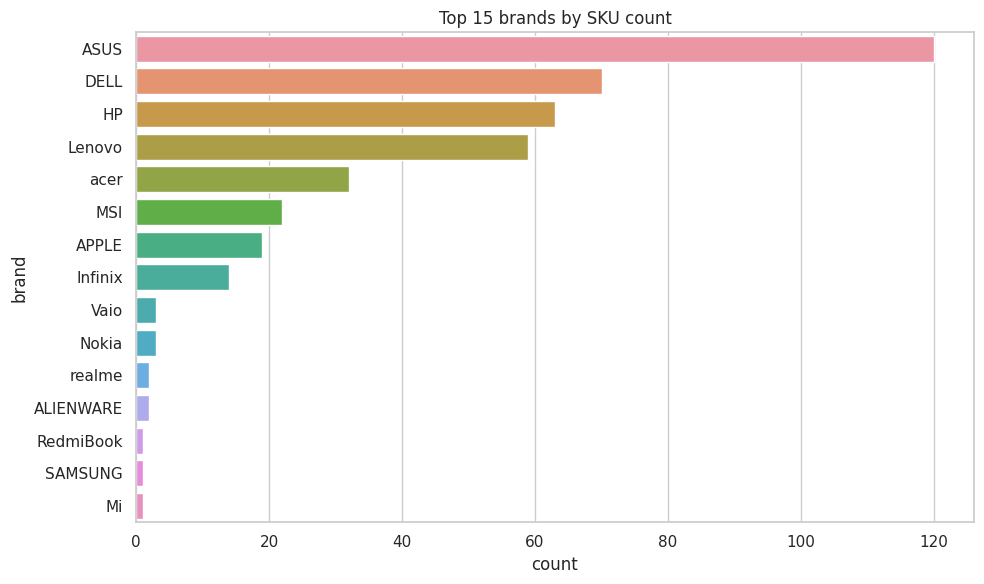

No 'category' column found.


In [28]:
# 6) Top categories: brand & category if present
if 'brand' in df.columns:
    top_brands = df['brand'].value_counts().nlargest(15).index
    plt.figure(figsize=(10,6))
    sns.countplot(data=df[df['brand'].isin(top_brands)], y='brand', order=top_brands)
    plt.title("Top 15 brands by SKU count")
    plt.tight_layout()
    plt.show()
else:
    print("No 'brand' column found.")

# Category (if exists)
if 'category' in df.columns:
    top_cats = df['category'].value_counts().nlargest(12).index
    plt.figure(figsize=(12,6))
    sns.countplot(data=df[df['category'].isin(top_cats)], x='category', order=top_cats)
    plt.xticks(rotation=45, ha='right')
    plt.title("Top 12 categories by SKU count")
    plt.tight_layout()
    plt.show()
else:
    print("No 'category' column found.")


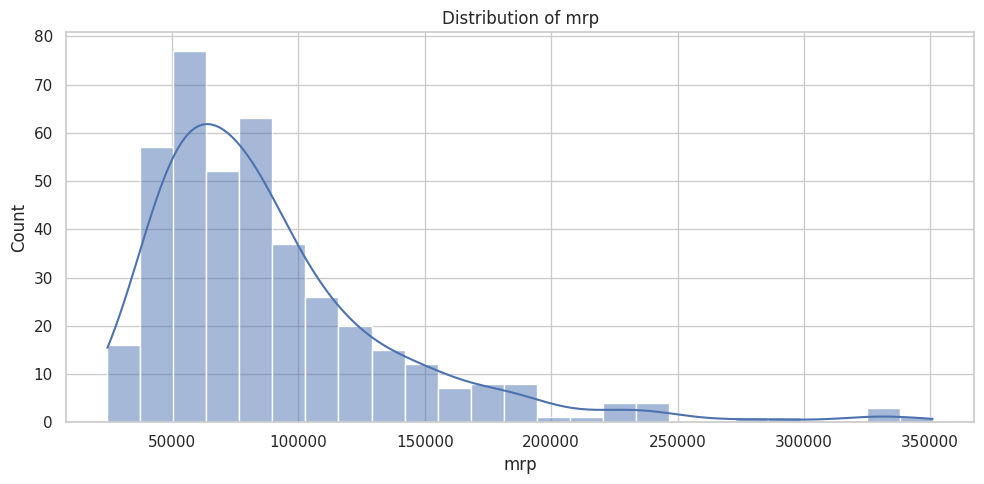

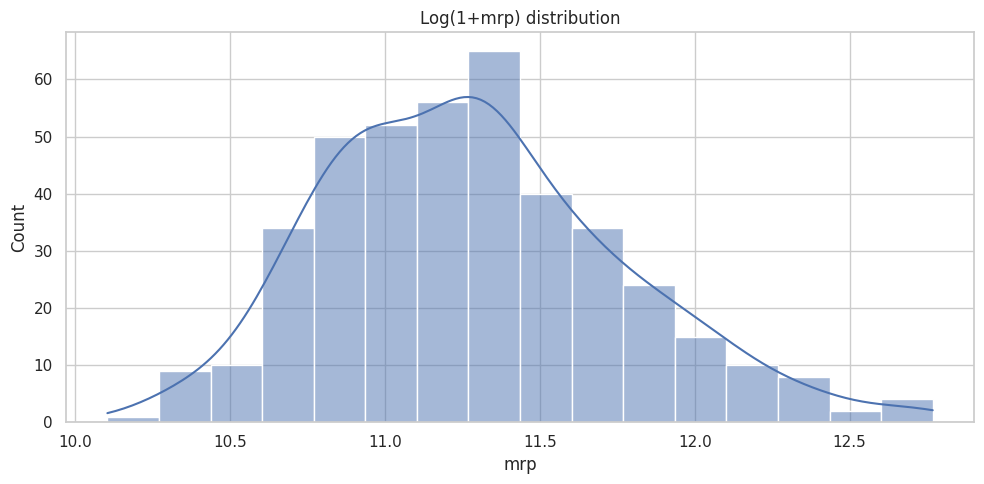

In [29]:
# 7) Price distributions: replace 'price' with best candidate if name differs
price_col = None
for candidate in ['price','selling_price','mrp','amount','list_price']:
    if candidate in df.columns:
        price_col = candidate
        break

if price_col:
    plt.figure(figsize=(10,5))
    sns.histplot(df[price_col].dropna(), kde=True)
    plt.title(f"Distribution of {price_col}")
    plt.tight_layout()
    plt.show()

    # log-scale distribution (useful if skewed)
    plt.figure(figsize=(10,5))
    sns.histplot(np.log1p(df[price_col].dropna()), kde=True)
    plt.title(f"Log(1+{price_col}) distribution")
    plt.tight_layout()
    plt.show()
else:
    print("No price-like column detected among candidates.")


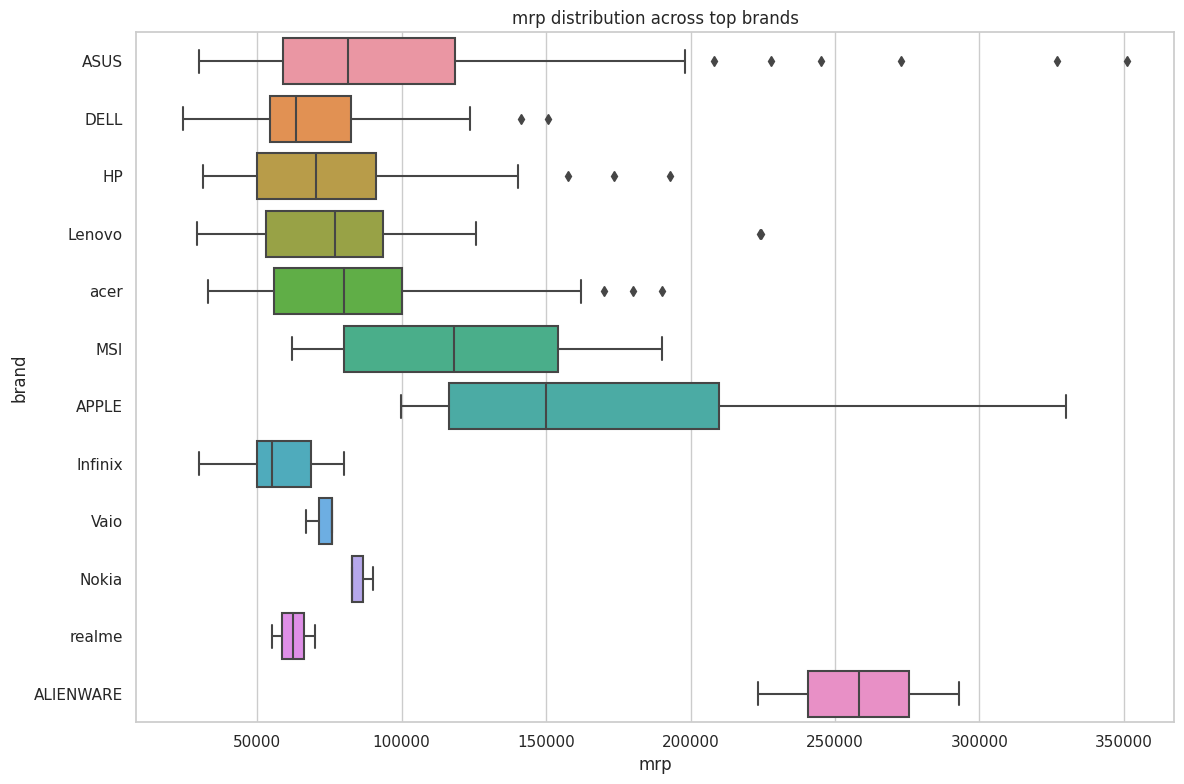

In [30]:
# 8) Boxplot price by brand (top brands only)
if price_col and 'brand' in df.columns:
    top_brands = df['brand'].value_counts().nlargest(12).index
    subset = df[df['brand'].isin(top_brands) & df[price_col].notna()]
    plt.figure(figsize=(12,8))
    sns.boxplot(data=subset, x=price_col, y='brand', order=top_brands)
    plt.title(f"{price_col} distribution across top brands")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping boxplot (need both price-like column and brand).")


In [31]:
# 9) Rating distribution and relationship with price
rating_col = None
for candidate in ['rating','avg_rating','rating_value','stars']:
    if candidate in df.columns:
        rating_col = candidate
        break

if rating_col:
    plt.figure(figsize=(8,4))
    sns.histplot(df[rating_col].dropna(), kde=True)
    plt.title(f"Distribution of {rating_col}")
    plt.tight_layout()
    plt.show()

    if price_col:
        plt.figure(figsize=(10,6))
        sns.scatterplot(data=df, x=price_col, y=rating_col, alpha=0.5)
        plt.title(f"{price_col} vs {rating_col}")
        plt.tight_layout()
        plt.show()
else:
    print("No rating-like column found; skipping rating plots.")


No rating-like column found; skipping rating plots.


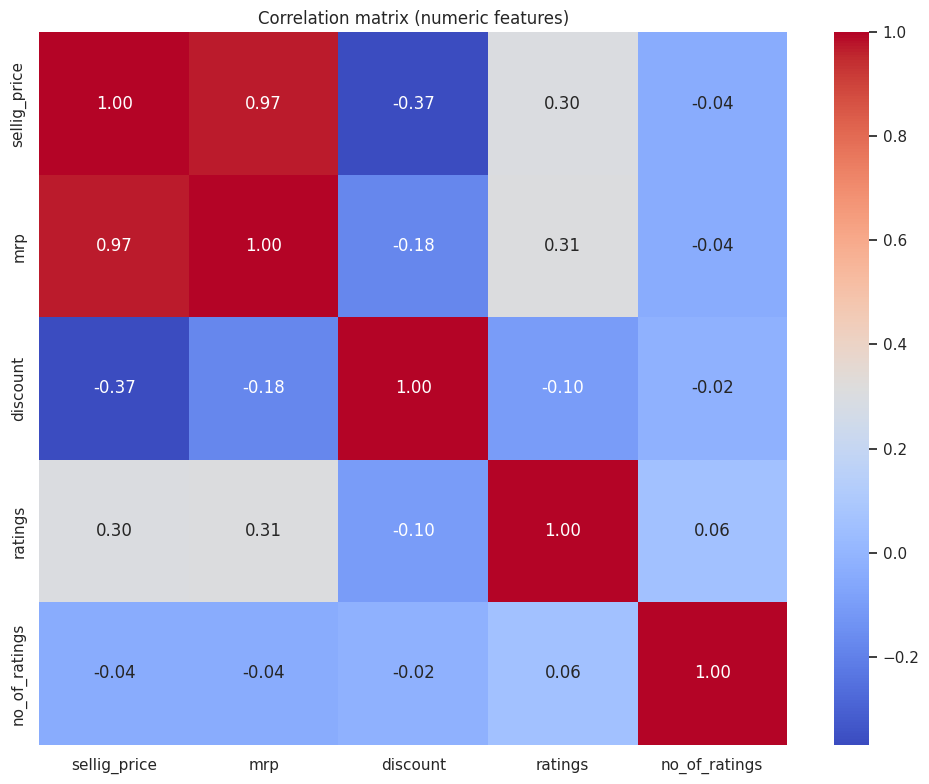

In [32]:
# 10) Correlation heatmap for numeric features
num_df = df.select_dtypes(include=[np.number]).copy()
if num_df.shape[1] >= 2:
    corr = num_df.corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=False)
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns to compute correlation.")


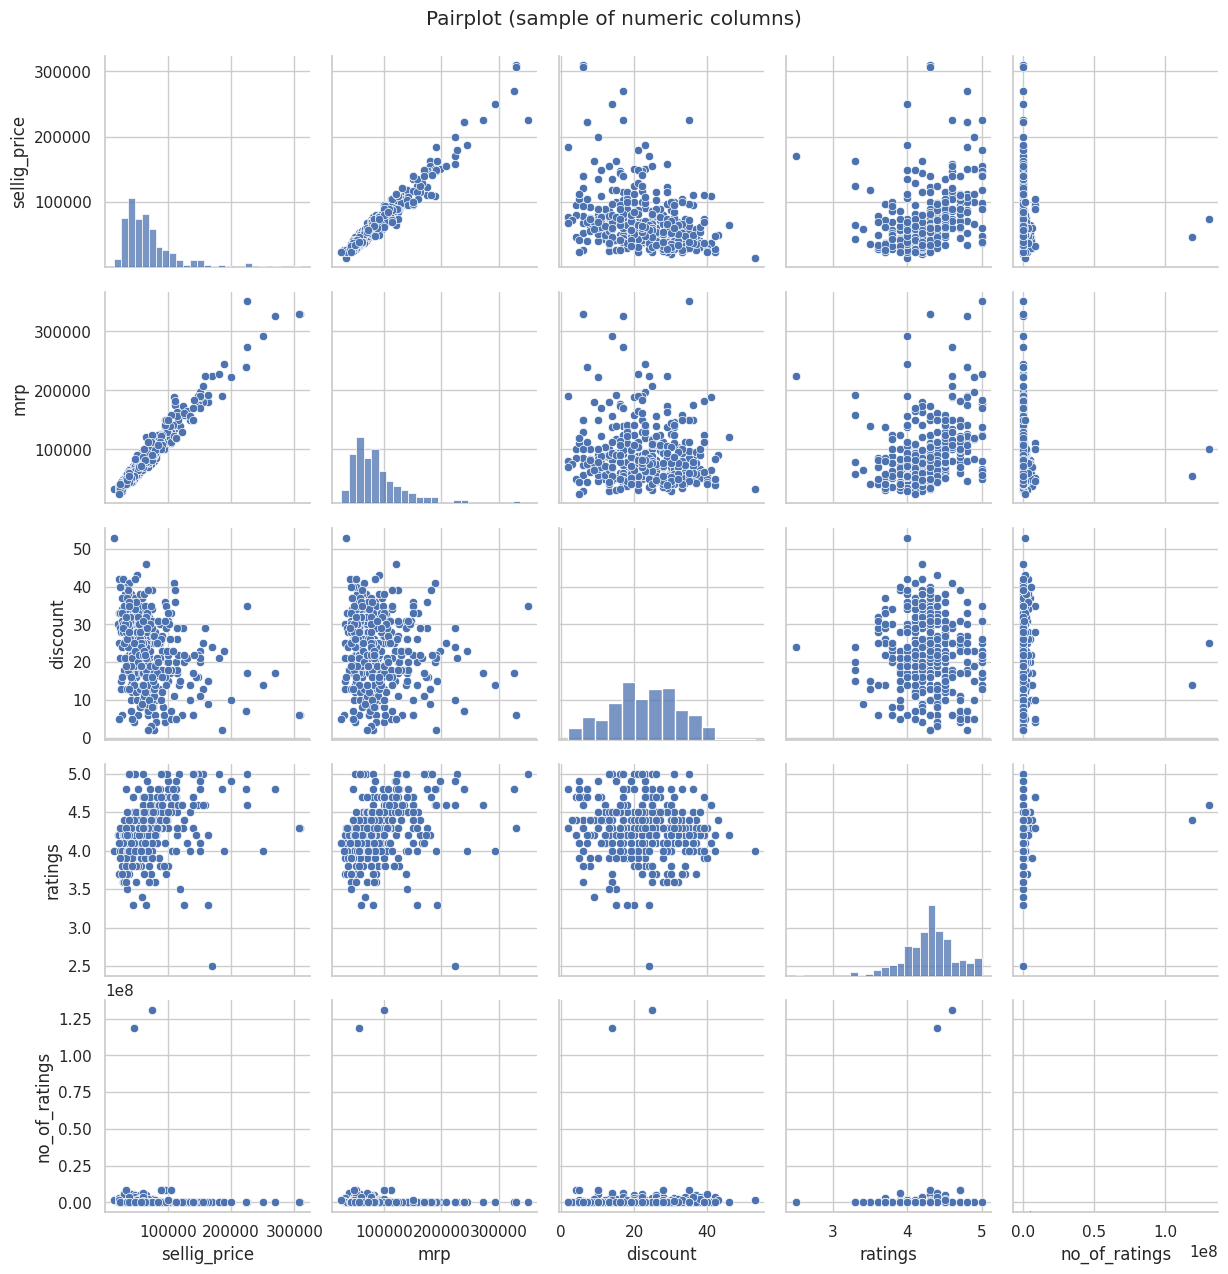

In [33]:
# 11) Pairplot sample (limit to avoid huge plotting)
pair_cols = list(num_df.columns)[:6]  # pick up to 6 numeric columns
if len(pair_cols) >= 2:
    sample = num_df[pair_cols].dropna().sample(n=min(500, num_df.dropna().shape[0]), random_state=1)
    sns.pairplot(sample)
    plt.suptitle("Pairplot (sample of numeric columns)", y=1.02)
    plt.show()
else:
    print("Not enough numeric columns for a pairplot.")
